# EDA 

## Objetivo

Este Notebook serve como exploração dos dados (EDA). As estruturas de código se localizam todas no arquivo eda.py, uma classe voltada exclusivamente para EDA de Datasets de forma automatizada.

## Estrutura da análise

A ánalise segue 3 passos sequênciais:

- Importação do Dataset (Telco_customer_churn) de forma local

- Visualização inicial dos dados

- EDA do dataset, analisando diversos aspectos como nulidade nas colunas, distribuição das features, valores únicos, correlações, etc

- EDA específica da target escolhida. No caso vislumbrou-se um MLP para classificação binária e um para score do Churn, logo se analisou Churn Value e Churn Score 

## Conclusões

O entendimento dos dados permite que na fase seguinte as seguintes ações possam ser planejadas dentro da classe python criada para o feature engineering sem a necessidade de retrabalho e/ou exploração dos dados novamente. As seguintes conclusões e premissas são levadas para o próximo passo

- As features Count, Country e State não agregam nenhuma valor, uma vez que são constantes em todo o dataset
- Zip Code, Lat Long, Latitude e Longitude não agregam valor ao futuro modelo, uma vez que nenhuma análise geoespacial será realizada e a informação da cidade já agrega o valor que elas trariam
- CustomerID é apenas o identificador único do cliente, sendo assim não há necessidade de mantê-lo no Dataset.
- Churn Label e Churn Value são redundantes. Por Churn Value já estar binarizada no formato numérico optou-se por mantê-la como Target
- Churn Reason é uma feature com data leakage, uma vez que apenas clientes com Churn Value = 1 possuem motivos para Churn. Numa análise descritiva do por que os clientes estão evadindo seria uma informação importante, porém para um modelo preditivo ela se torna Leakage.
- As features cadastrais, como indicativo de dependentes, gênero, entre outras, devem ser binarizadas
- Tenure Months e CLTV parecem fortes candidatas a bucketização para trazer mais valor ao modelo.
- É possível traçar um "perfil" do cliente de acordo com os serviços contratados.

## Decisões para modelagem

- O alvo do projeto é `Churn Value`, pois representa diretamente o cancelamento observado.
- `Churn Reason` e `Churn Label` não podem ser usados como features: são informações conhecidas após o cancelamento ou redundantes do alvo.
- `Churn Score` será excluído das features e não será tratado como segundo alvo. Usar um score cuja disponibilidade no momento da inferência não foi comprovada pode introduzir leakage.
- O desbalanceamento de `Churn Value` será considerado na escolha do modelo por F1 como métrica principal, recall como métrica de proteção e AUC-ROC como métrica complementar.
- O pré-processamento deve ser ajustado somente nos dados de treino; o pipeline produtivo aplica imputação e escala dentro da validação cruzada.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'notebooks'))

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_excel(PROJECT_ROOT / 'data' / 'Telco_customer_churn.xlsx')

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
lista_colunas = df.columns.tolist()
qualidade_dados = pd.DataFrame({
    'linhas': [df.shape[0]],
    'colunas': [df.shape[1]],
    'linhas_duplicadas': [int(df.duplicated().sum())],
    'valores_ausentes': [int(df.isna().sum().sum())],
})
display(qualidade_dados)

qualidade_colunas = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'ausentes': df.isna().sum(),
    'percentual_ausentes': (df.isna().mean() * 100).round(2),
    'valores_unicos': df.nunique(dropna=False),
}).sort_values(['percentual_ausentes', 'valores_unicos'], ascending=[False, True])
display(qualidade_colunas)

,linhas,colunas,linhas_duplicadas,valores_ausentes
0,7043,33,0,5174


,tipo,ausentes,percentual_ausentes,valores_unicos
Churn Reason,object,5174,73.46,21
Count,int64,0,0.00,1
Country,object,0,0.00,1
State,object,0,0.00,1
Gender,object,0,0.00,2
Senior Citizen,object,0,0.00,2
Partner,object,0,0.00,2
Dependents,object,0,0.00,2
Phone Service,object,0,0.00,2
Paperless Billing,object,0,0.00,2


In [18]:
from eda import EDA
eda = EDA(df)

In [8]:
eda.valores_unicos()


CONTAGEM DE VALORES ÚNICOS
           Coluna  Valores Únicos  Percentual (%)
       CustomerID            7043          100.00
            Count               1            0.01
          Country               1            0.01
            State               1            0.01
             City            1129           16.03
         Zip Code            1652           23.46
         Lat Long            1652           23.46
         Latitude            1652           23.46
        Longitude            1651           23.44
           Gender               2            0.03
   Senior Citizen               2            0.03
          Partner               2            0.03
       Dependents               2            0.03
    Tenure Months              73            1.04
    Phone Service               2            0.03
   Multiple Lines               3            0.04
 Internet Service               3            0.04
  Online Security               3            0.04
    Online Backup     


RELATÓRIO COMPLETO DE EDA - EXPLORATORY DATA ANALYSIS

INFORMAÇÕES GERAIS DO DATASET
Dimensões: 7043 linhas × 33 colunas

Tipos de dados:
CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
Churn Label              str
Churn Value         

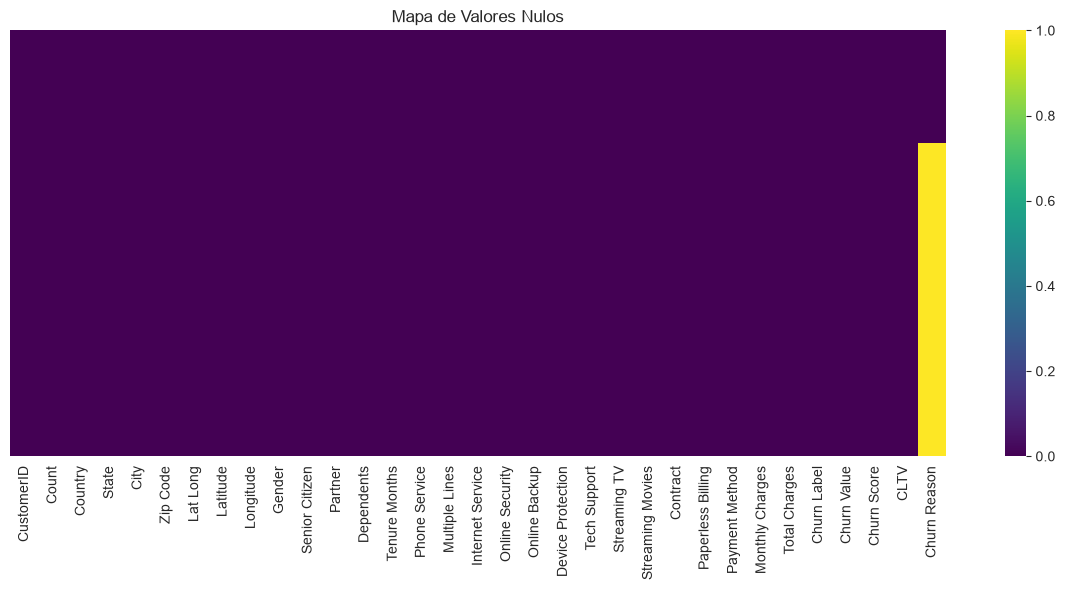


CONTAGEM DE VALORES ÚNICOS
           Coluna  Valores Únicos  Percentual (%)
       CustomerID            7043          100.00
            Count               1            0.01
          Country               1            0.01
            State               1            0.01
             City            1129           16.03
         Zip Code            1652           23.46
         Lat Long            1652           23.46
         Latitude            1652           23.46
        Longitude            1651           23.44
           Gender               2            0.03
   Senior Citizen               2            0.03
          Partner               2            0.03
       Dependents               2            0.03
    Tenure Months              73            1.04
    Phone Service               2            0.03
   Multiple Lines               3            0.04
 Internet Service               3            0.04
  Online Security               3            0.04
    Online Backup     

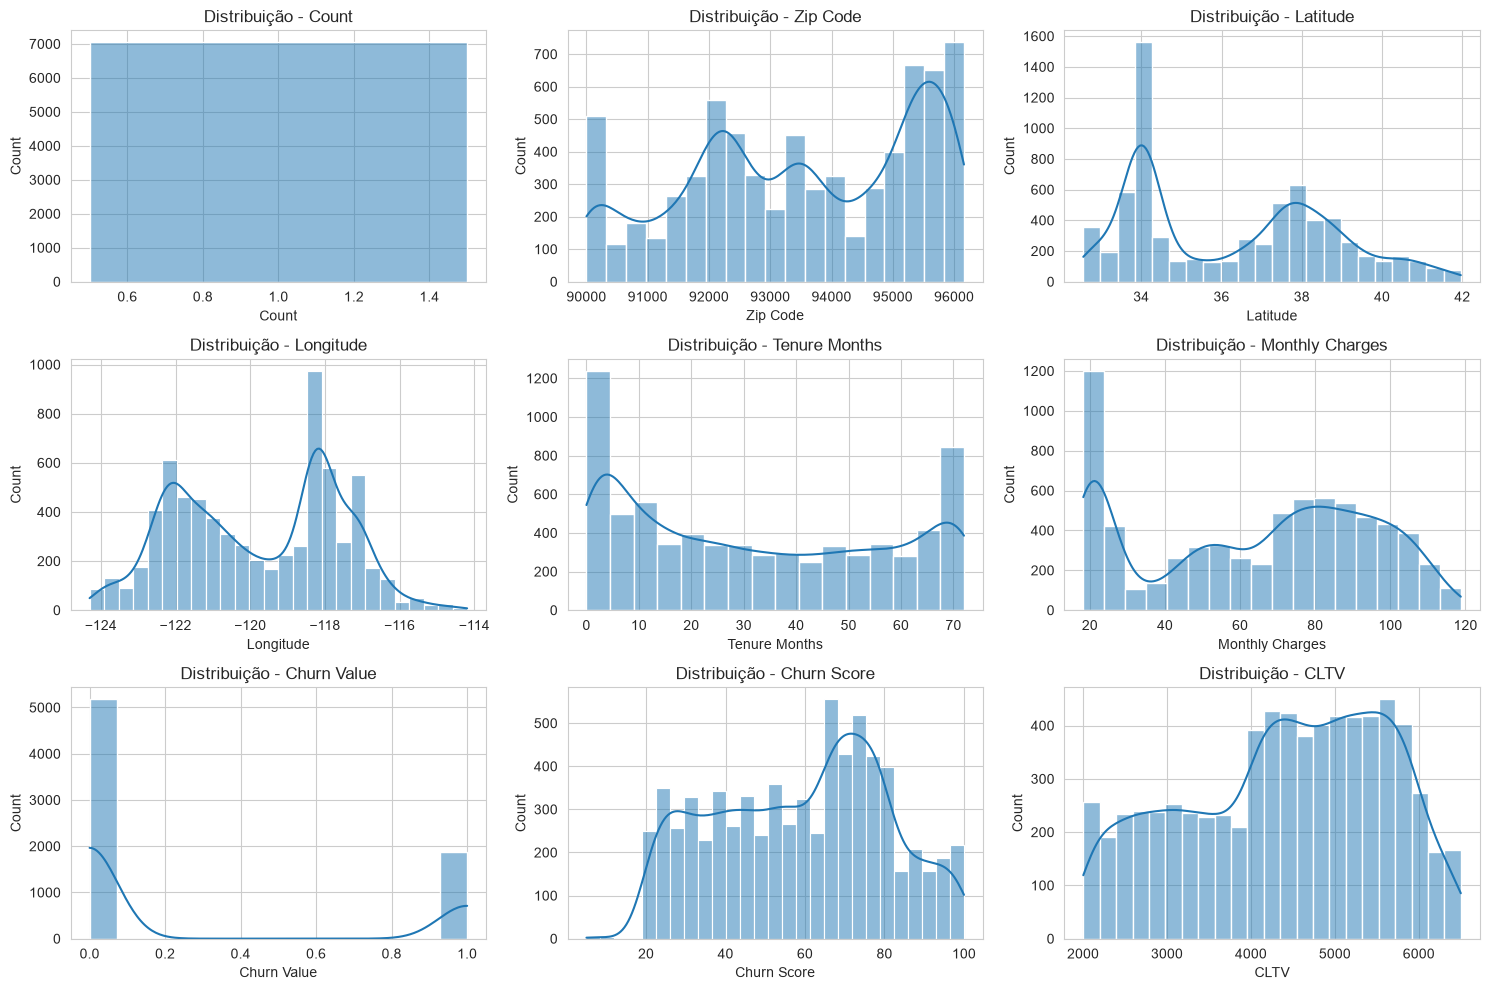

c:\Users\gui08\OneDrive\Documentos\Tech_challenge_1\eda.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=series, ax=axes[idx], palette='Set2')
c:\Users\gui08\OneDrive\Documentos\Tech_challenge_1\eda.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=series, ax=axes[idx], palette='Set2')
c:\Users\gui08\OneDrive\Documentos\Tech_challenge_1\eda.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=series, ax=axes[idx], palette='Set2')
c:\Users\gui08\OneDrive\Documentos\Tech_challenge_1\eda.py:153: FutureWarning: 

Passing `palette

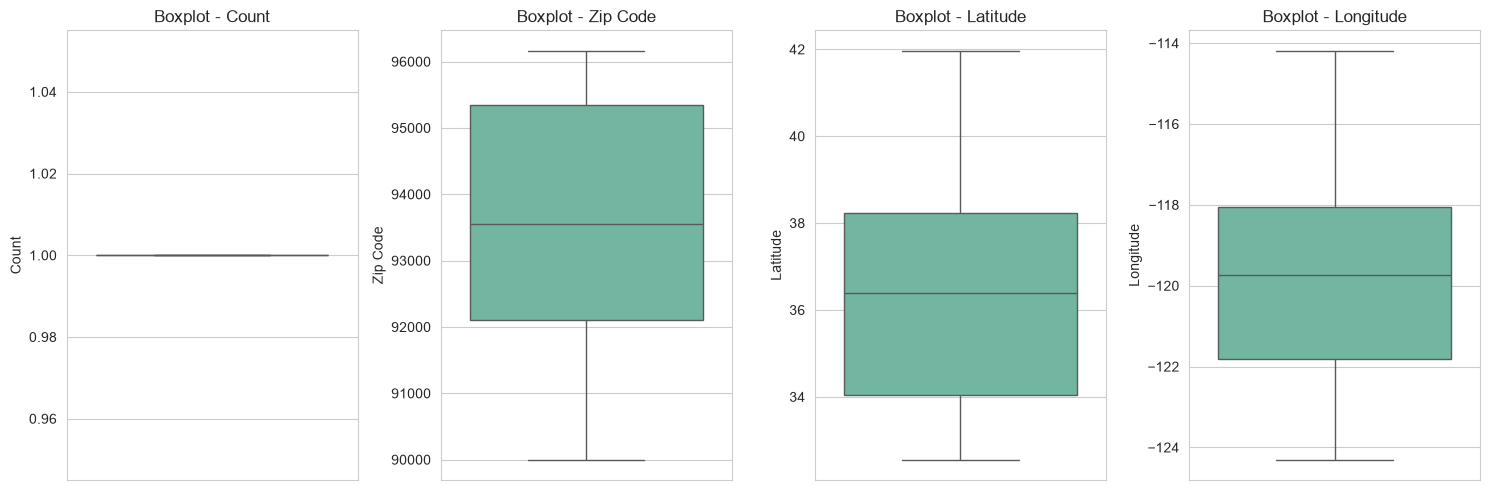


CustomerID:
CustomerID
3668-QPYBK    1
9237-HQITU    1
9305-CDSKC    1
7892-POOKP    1
0280-XJGEX    1
4190-MFLUW    1
8779-QRDMV    1
1066-JKSGK    1
6467-CHFZW    1
8665-UTDHZ    1
Name: count, dtype: int64


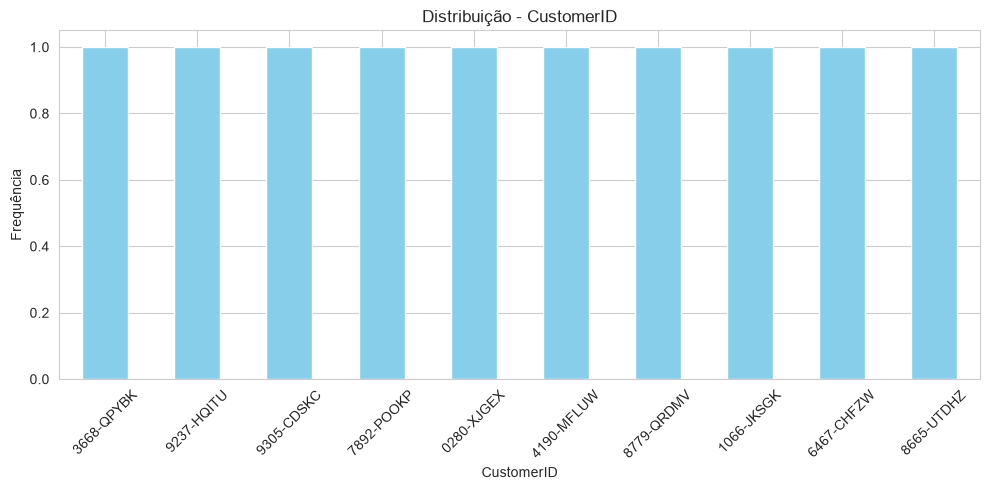


Country:
Country
United States    7043
Name: count, dtype: int64


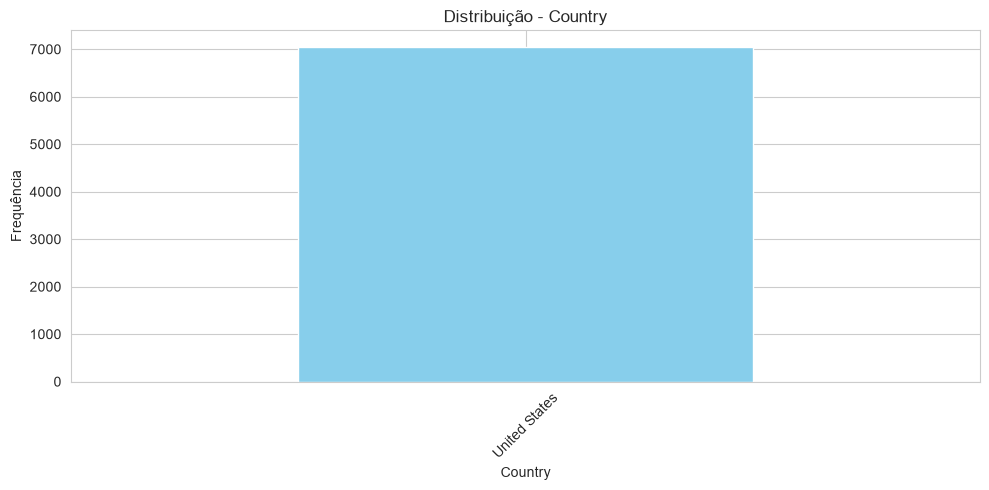


State:
State
California    7043
Name: count, dtype: int64


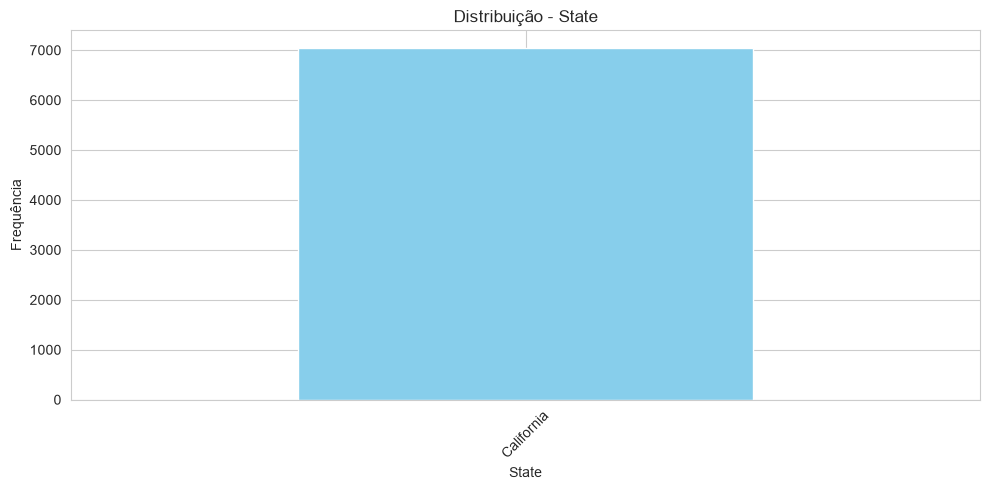


City:
City
Los Angeles      305
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
Fresno            64
Long Beach        60
Oakland           52
Stockton          44
Glendale          40
Name: count, dtype: int64


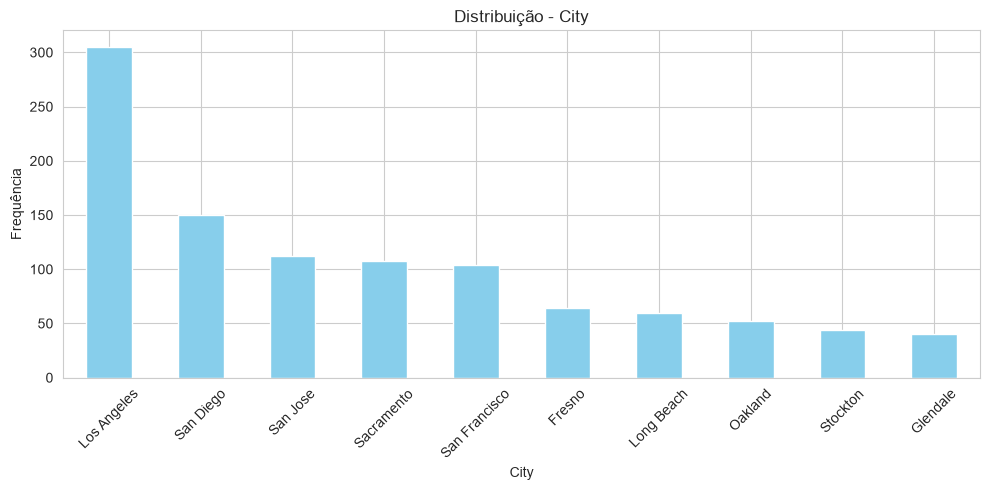


MATRIZ DE CORRELAÇÃO (PEARSON)
                 Count  Zip Code  Latitude  Longitude  Tenure Months  \
Count              NaN       NaN       NaN        NaN            NaN   
Zip Code           NaN  1.000000  0.895743  -0.784271       0.001041   
Latitude           NaN  0.895743  1.000000  -0.876779      -0.001631   
Longitude          NaN -0.784271 -0.876779   1.000000      -0.001678   
Tenure Months      NaN  0.001041 -0.001631  -0.001678       1.000000   
Monthly Charges    NaN -0.004596 -0.019899   0.024098       0.247900   
Churn Value        NaN  0.003346 -0.003384   0.004594      -0.352229   
Churn Score        NaN -0.002769 -0.007684   0.004260      -0.224987   
CLTV               NaN -0.003562  0.000886   0.000485       0.396406   

                 Monthly Charges  Churn Value  Churn Score      CLTV  
Count                        NaN          NaN          NaN       NaN  
Zip Code               -0.004596     0.003346    -0.002769 -0.003562  
Latitude               -0.019899  

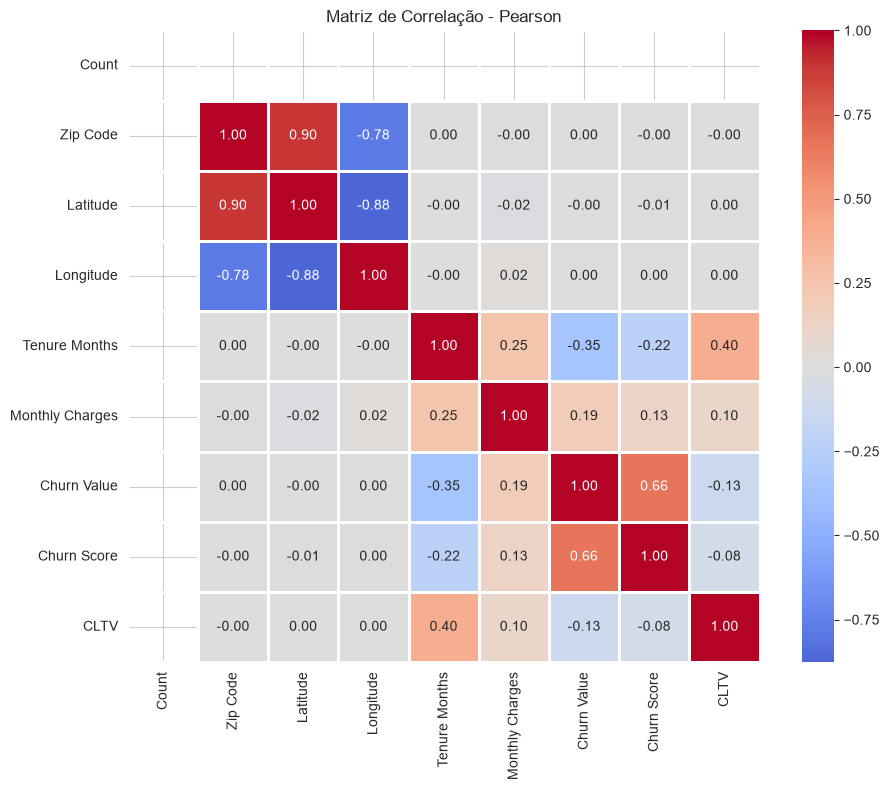


DETECÇÃO DE OUTLIERS (Método: IQR)
Count: 0 outliers (0.00%)
Zip Code: 0 outliers (0.00%)
Latitude: 0 outliers (0.00%)
Longitude: 0 outliers (0.00%)
Tenure Months: 0 outliers (0.00%)
Monthly Charges: 0 outliers (0.00%)
Churn Value: 0 outliers (0.00%)
Churn Score: 0 outliers (0.00%)
CLTV: 0 outliers (0.00%)

FIM DO RELATÓRIO DE EDA


In [6]:

eda.relatorio_completo(colunas=lista_colunas)

In [10]:
lista_colunas

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

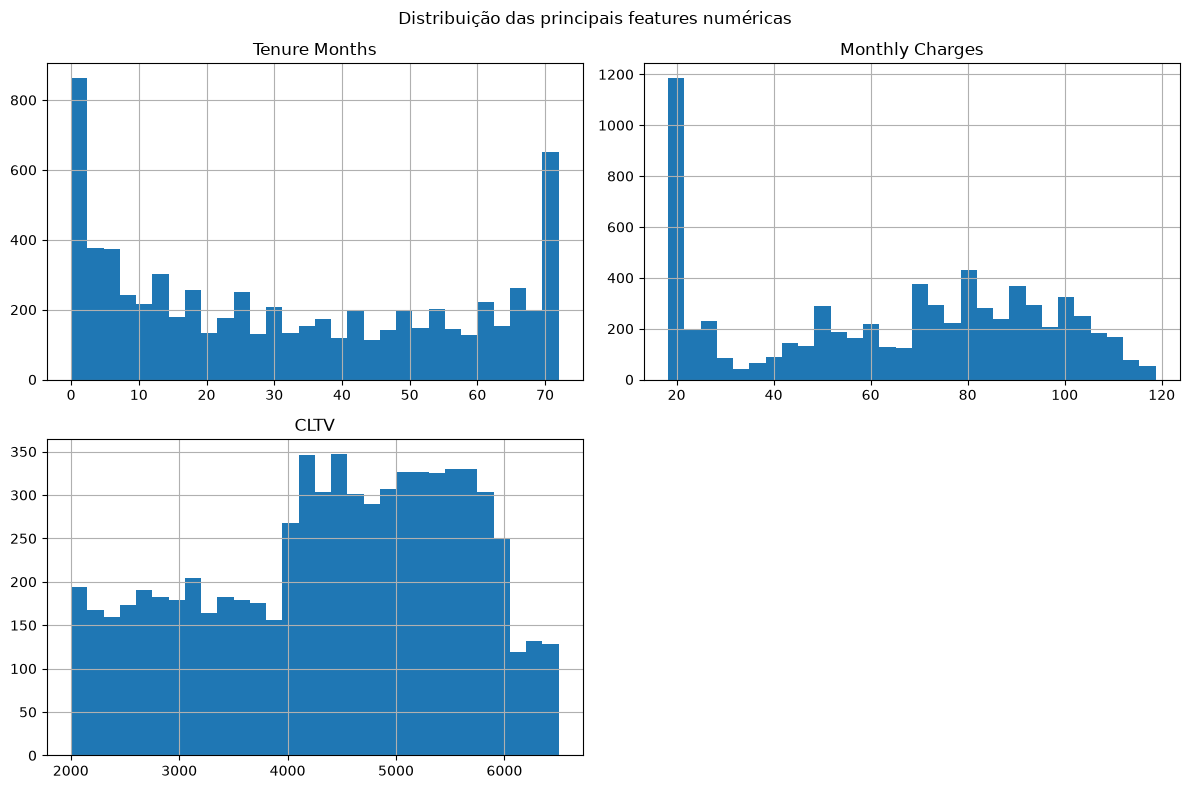

In [5]:
features_numericas_chave = [
    coluna for coluna in ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
    if coluna in df.columns
]
df[features_numericas_chave].hist(figsize=(12, 8), bins=30)
plt.suptitle('Distribuição das principais features numéricas')
plt.tight_layout()

In [7]:
eda.correlacao_com_target(target='Churn Value')


TOP 10 CORRELAÇÕES COM 'Churn Value'
Churn Value        1.000000
Churn Score        0.664897
Monthly Charges    0.193356
Longitude          0.004594
Zip Code           0.003346
Latitude          -0.003384
CLTV              -0.127463
Tenure Months     -0.352229
Count                   NaN
Name: Churn Value, dtype: float64


Churn Value        1.000000
Churn Score        0.664897
Monthly Charges    0.193356
Longitude          0.004594
Zip Code           0.003346
Latitude          -0.003384
CLTV              -0.127463
Tenure Months     -0.352229
Count                   NaN
Name: Churn Value, dtype: float64

,quantidade,percentual
Churn Value,,
0,5174,73.46
1,1869,26.54


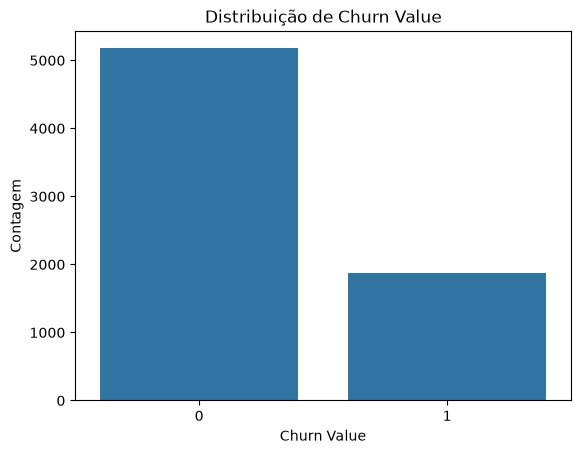

In [7]:
target = 'Churn Value'
distribuicao_target = pd.DataFrame({
    'quantidade': df[target].value_counts(dropna=False),
    'percentual': (df[target].value_counts(normalize=True, dropna=False) * 100).round(2),
})
display(distribuicao_target)

sns.countplot(data=df, x=target)
plt.title(f'Distribuição de {target}')
plt.xlabel(target)
plt.ylabel('Contagem')
plt.show()

In [8]:
features_categoricas_chave = [
    coluna for coluna in ['Contract', 'Internet Service', 'Payment Method']
    if coluna in df.columns
]
taxa_churn_categorias = pd.concat([
    df.groupby(coluna, dropna=False)[target].mean().mul(100).rename(coluna)
    for coluna in features_categoricas_chave
], axis=1)
taxa_churn_categorias

,Contract,Internet Service,Payment Method
Month-to-month,42.709677,NaN,NaN
One year,11.269518,NaN,NaN
Two year,2.831858,NaN,NaN
DSL,NaN,18.959108,NaN
Fiber optic,NaN,41.892765,NaN
No,NaN,7.404980,NaN
Bank transfer (automatic),NaN,NaN,16.709845
Credit card (automatic),NaN,NaN,15.243101
Electronic check,NaN,NaN,45.285412
Mailed check,NaN,NaN,19.106700
